# Prac 06.1

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [19]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
import dlib
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

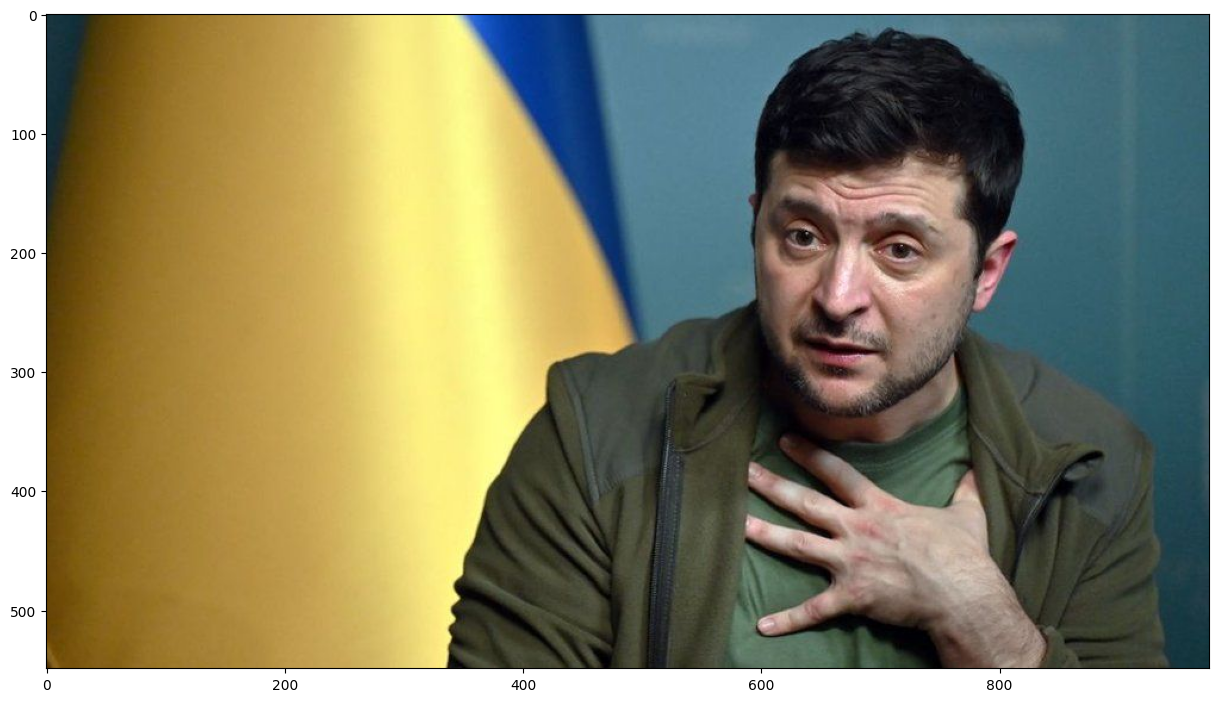

In [20]:
img = cv2.imread('data/zelensky.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)

### Step 2

Load the dlib face predictor.

### Step 3

Run the predictor on your image.

In [21]:
detector = dlib.get_frontal_face_detector()
rects = detector(gray, 1)

print('Number of detected faces:', len(rects))
print(rects)
print(rects[0].left)

Number of detected faces: 1
rectangles[[(563, 118) (786, 341)]]
<bound method PyCapsule.left of rectangle(563,118,786,341)>


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

563 118 223 223


(<Axes: >, <matplotlib.image.AxesImage at 0x25a69035ed0>)

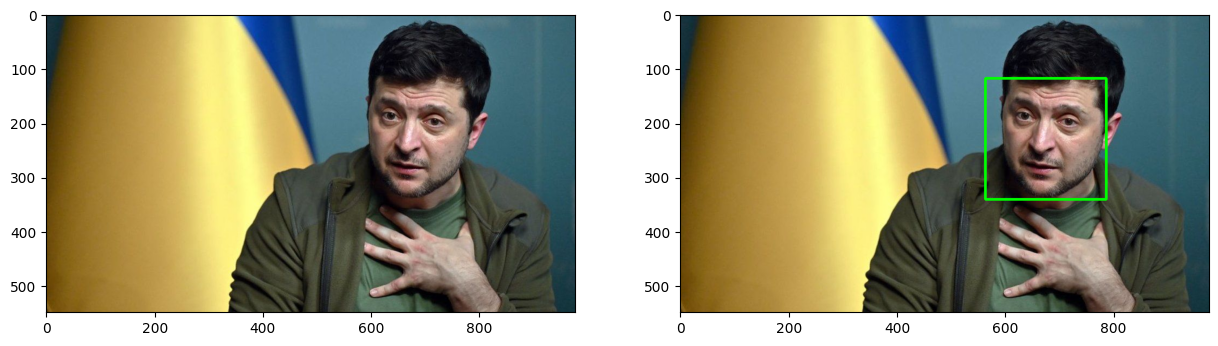

In [22]:
def rect_to_bb(rect):
    # Dlib rect --> OpenCV rect
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y

    return (x, y, w, h)


result_dlib = np.copy(img)
faces_dlib_img = []
for rect in rects:
    x, y, w, h = rect_to_bb(rect)
    print(x, y, w, h)
    cv2.rectangle(result_dlib, (x, y), (x+w, y+h), (0, 255, 0), 3)
    faces_dlib_img.append(img[y:y+h, x:x+w, :])


plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(result_dlib)

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Number of detected faces: 8
rectangles[[(170, 65) (213, 108)], [(309, 161) (352, 204)], [(607, 32) (659, 84)], [(383, 67) (435, 118)], [(501, 22) (544, 65)], [(136, 151) (180, 194)], [(12, 60) (55, 103)], [(492, 130) (544, 182)]]
<bound method PyCapsule.left of rectangle(170,65,213,108)>
170 65 43 43
309 161 43 43
607 32 52 52
383 67 52 51
501 22 43 43
136 151 44 43
12 60 43 43
492 130 52 52


(<Axes: >, <matplotlib.image.AxesImage at 0x25a6b0cc190>)

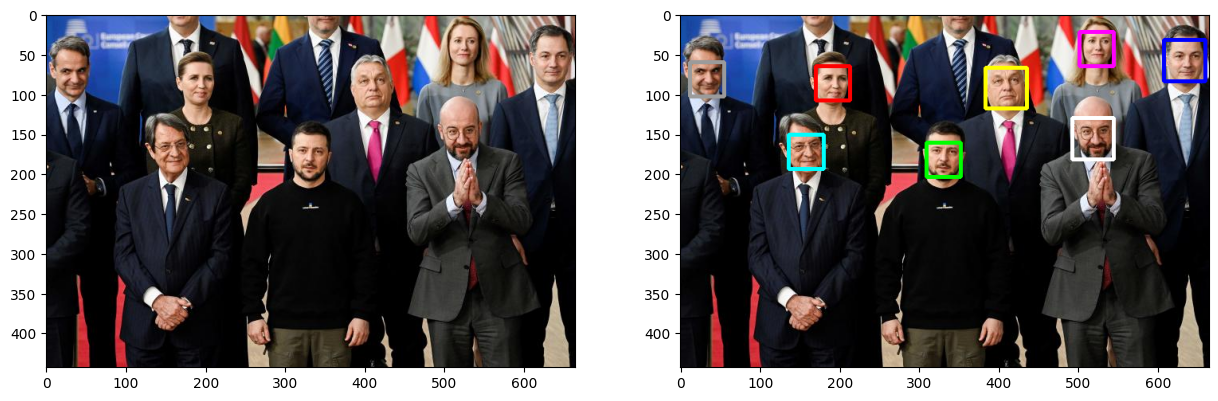

In [30]:
img_more = cv2.imread('data/eu_summit.jpg')
img_more = cv2.cvtColor(img_more, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_more, cv2.COLOR_RGB2GRAY)

detector = dlib.get_frontal_face_detector()
rects = detector(gray, 1)

print('Number of detected faces:', len(rects))
print(rects)
print(rects[0].left)

my_colors = [
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255),
    (255, 255, 0),
    (255, 0, 255),
    (0, 255, 255),
    (155, 155, 155),
    (255, 255, 255)
]

def rect_to_bb(rect):
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y

    return (x, y, w, h)


result_dlib = np.copy(img_more)
faces_dlib_img = []
for i, rect in enumerate(rects):
    x, y, w, h = rect_to_bb(rect)
    color = my_colors[i % len(my_colors)]
    print(x, y, w, h)
    cv2.rectangle(result_dlib, (x, y), (x+w, y+h), color, 3)
    faces_dlib_img.append(img_more[y:y+h, x:x+w, :])


plt.subplot(121), plt.imshow(img_more)
plt.subplot(122), plt.imshow(result_dlib)